In [9]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
rng = np.random.default_rng(42)


In [10]:
def bs_call_price(S, K, r, sigma, T):
    if T <= 0 or sigma <= 0:
        return max(S - K, 0.0)
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


In [11]:
def gen_S_T_vectorized(S0, mu, sigma, T, N_paths, N_steps, rng):
    dt = T / N_steps
    Z = rng.standard_normal((N_paths, N_steps))
    increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.cumsum(increments, axis=1)
    log_S_T = np.log(S0) + log_paths[:, -1]
    return np.exp(log_S_T)  # shape (N_paths,)


In [12]:
def gen_S_T_antithetic(S0, mu, sigma, T, N_paths, N_steps, rng):
    half = N_paths // 2
    Z = rng.standard_normal((half, N_steps))
    Z_pair = np.vstack([Z, -Z])
    dt = T / N_steps
    increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z_pair
    log_paths = np.cumsum(increments, axis=1)
    log_S_T = np.log(S0) + log_paths[:, -1]
    return np.exp(log_S_T)


In [13]:
def mc_price_call_naive(S0, K, r, mu, sigma, T, N_paths, N_steps, rng):
    S_T = gen_S_T_vectorized(S0, mu, sigma, T, N_paths, N_steps, rng)
    pay = np.maximum(S_T - K, 0.0)
    price = np.exp(-r*T) * pay.mean()
    se = np.exp(-r*T) * pay.std(ddof=1) / np.sqrt(N_paths)
    return price, se, pay

def mc_price_call_antithetic(S0, K, r, mu, sigma, T, N_paths, N_steps, rng):
    if N_paths % 2 != 0:
        N_paths += 1
    S_T = gen_S_T_antithetic(S0, mu, sigma, T, N_paths, N_steps, rng)
    pay = np.maximum(S_T - K, 0.0)
    price = np.exp(-r*T) * pay.mean()
    se = np.exp(-r*T) * pay.std(ddof=1) / np.sqrt(N_paths)
    return price, se, pay

def mc_price_call_control_variate(S0, K, r, mu, sigma, T, N_paths, N_steps, rng):
    S_T = gen_S_T_vectorized(S0, mu, sigma, T, N_paths, N_steps, rng)
    pay = np.maximum(S_T - K, 0.0)
    # choose control = S_T (known E[S_T] under GBM with drift mu)
    control = S_T
    E_control = S0 * np.exp(mu * T)
    cov = np.cov(pay, control, ddof=1)[0,1]
    var_control = np.var(control, ddof=1)
    beta = cov / var_control if var_control > 0 else 0.0
    adjusted = pay + beta * (E_control - control)
    price = np.exp(-r*T) * adjusted.mean()
    se = np.exp(-r*T) * adjusted.std(ddof=1) / np.sqrt(N_paths)
    return price, se, pay, adjusted


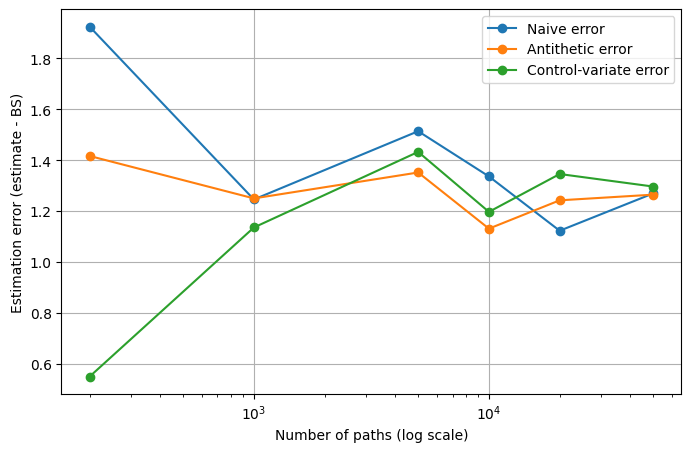

,naive_se,antithetic_se,cv_se
N,,,
200,1.153486,1.066713,0.378351
1000,0.471938,0.472268,0.178291
5000,0.217912,0.215486,0.082496
10000,0.151147,0.148900,0.057570
20000,0.105598,0.106563,0.040835
50000,0.067186,0.067073,0.025750


In [14]:
S0, K, r, mu, sigma, T, N_steps = 100.0, 100.0, 0.03, 0.05, 0.2, 1.0, 252
true_price = bs_call_price(S0, K, r, sigma, T)

path_sizes = [200, 1000, 5000, 10000, 20000, 50000]
results = []
for N in path_sizes:
    t0 = time.time()
    p_naive, se_naive, _ = mc_price_call_naive(S0, K, r, mu, sigma, T, N, N_steps, rng)
    t1 = time.time()
    p_anti, se_anti, _ = mc_price_call_antithetic(S0, K, r, mu, sigma, T, N, N_steps, rng)
    p_cv, se_cv, _, _ = mc_price_call_control_variate(S0, K, r, mu, sigma, T, N, N_steps, rng)
    results.append({
        'N': N,
        'naive_price': p_naive, 'naive_se': se_naive,
        'antithetic_price': p_anti, 'antithetic_se': se_anti,
        'cv_price': p_cv, 'cv_se': se_cv,
        'time_s': time.time()-t0
    })

df = pd.DataFrame(results)
df['naive_err'] = df['naive_price'] - true_price
df['anti_err'] = df['antithetic_price'] - true_price
df['cv_err'] = df['cv_price'] - true_price

plt.figure(figsize=(8,5))
plt.plot(df['N'], df['naive_err'], marker='o', label='Naive error')
plt.plot(df['N'], df['anti_err'], marker='o', label='Antithetic error')
plt.plot(df['N'], df['cv_err'], marker='o', label='Control-variate error')
plt.xscale('log')
plt.xlabel('Number of paths (log scale)')
plt.ylabel('Estimation error (estimate - BS)')
plt.legend()
plt.grid(True)
plt.show()

df[['N','naive_se','antithetic_se','cv_se']].set_index('N')


In [15]:
# compare se at largest N
largest = df.iloc[-1]
vrf_anti = (largest['naive_se']**2) / (largest['antithetic_se']**2)  # variance ratio
vrf_cv = (largest['naive_se']**2) / (largest['cv_se']**2)
pd.DataFrame({
    'method': ['antithetic','control_variate'],
    'variance_reduction_factor': [vrf_anti, vrf_cv]
})


,method,variance_reduction_factor
0,antithetic,1.003385
1,control_variate,6.807642


In [16]:
# Model: if you buy q shares at price S0 and liquidate at S_T (no transaction costs),
# PnL = q*(S_T - S0). Compute Pr(PnL < -L) where L is loss threshold (money).
def prob_loss_exceeds(q, loss_threshold, S0, mu, sigma, T, N_paths, N_steps, rng):
    S_T = gen_S_T_vectorized(S0, mu, sigma, T, N_paths, N_steps, rng)
    pnl = q * (S_T - S0)
    return np.mean(pnl < -loss_threshold)

# Example: what q gives <5% chance of losing more than $1000
target_prob = 0.05
loss_threshold = 1000.0
N_sim = 20000
# brute force scan q
qs = np.arange(1,200,1)
probs = [prob_loss_exceeds(q, loss_threshold, S0, mu, sigma, T, N_sim, N_steps, rng) for q in qs]
df_q = pd.DataFrame({'q': qs, 'prob_loss': probs})
recommended_q = df_q[df_q['prob_loss'] <= target_prob]['q'].max()
recommended_q, df_q.head()


(np.int64(38),
    q  prob_loss
 0  1        0.0
 1  2        0.0
 2  3        0.0
 3  4        0.0
 4  5        0.0)